# Mode survey — undriven rotor, 2026-09-09 evening

**Purpose:** find the rotor's natural frequencies, so we know what the drive can excite.

The rotor visibly wobbles at certain drive frequencies. If those coincide with rigid-body or structural modes, that is a resonance we are hitting — and it may be what limits pull-out, in which case more drive torque would not help.

### Why this data and not the spindown

A mode survey needs the rotor **undriven and not rotating**:

- **Driven** data is contaminated by the forced response at the drive frequency and its harmonics.
- **Rotating** data is worse: a spinning rotor puts strong lines at harmonics of its rotation rate, which are forced, not natural, and would dominate the spectrum.

These two windows are after the 09-09 capture into libration, overnight, with the electrodes off. The rotor sits in the trap being jostled by ambient noise — so every peak is something the system *wants* to do.

| window | front-end GPS | length |
|---|---|---|
| W1 | 1473050000 – 1473053600 | 1 h |
| W2 | 1473065000 – 1473068600 | 1 h |

**Two windows on purpose.** Real modes sit at the same frequency in both. Libration harmonics move, because the libration frequency drifts as its amplitude decays. That is the cleanest way to tell them apart, and it costs nothing.

### What to be suspicious of

- **Mains and its harmonics** — 50/60 Hz and multiples.
- **Exact integers** (16.000, 32.000, 48.000) — digital or clock artefacts, not mechanics.
- **LES dropouts.** On 09-09 the beam was lost for ~2 s during the sweep, which railed PIT to nonsense and made it look like a huge tilt excursion. `LES_SUM` is checked explicitly below before anything else is believed.

In [1]:
import numpy as np, matplotlib.pyplot as plt, os, h5py, subprocess
from scipy.signal import welch, decimate, coherence
from scipy.ndimage import median_filter

WINDOWS = {'W1': (1473050000, 1473053600),
           'W2': (1473065000, 1473068600)}
CHANS = {'YAW': ('Y1_RDS-LES_YAW_IN1_DQ', 'LES_yaw'),
         'PIT': ('Y1_RDS-LES_PIT_IN1_DQ', 'LES_pit'),
         'SUM': ('Y1_RDS-LES_SUM_IN1_DQ', 'LES_sum'),
         'DRV': ('Y1_RDS-OUTS_V2_OUT_DQ', 'Electrodes')}
SEARCH = ['../lab_utils/data', 'data', '.']

def get_h5(stem, sub, a, b):
    fn = f'{stem}_{a}_{b}.h5'
    for d in SEARCH:
        p = os.path.join(d, fn)
        if os.path.exists(p): return p
    os.makedirs('data', exist_ok=True)
    print(f'fetching {fn} from Dropbox...')
    subprocess.run(['rclone','copyto',
                    f'dropbox:Microspheres/TFINER/data/{sub}/{fn}',
                    f'data/{fn}'], check=True)
    return f'data/{fn}'

def load(path):
    with h5py.File(path,'r') as f:
        y  = np.asarray(f['data'], float)
        fs = float(f.attrs['sample_rate'])
    return y, fs

D = {}
for w,(a,b) in WINDOWS.items():
    D[w] = {}
    for k,(stem,sub) in CHANS.items():
        y, fs = load(get_h5(stem, sub, a, b))
        D[w][k] = y
    D[w]['fs'] = fs
    print(f'{w}: {len(D[w]["YAW"])/fs:.0f} s at {fs:.0f} Hz')

/tmp/ipykernel_1343883/2141720296.py:2: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.signal import welch, decimate, coherence


W1: 3600 s at 1024 Hz


W2: 3600 s at 1024 Hz


## 1. Sanity: is it really undriven, and did the beam stay on?

Both checks must pass before any peak in this notebook means anything.

In [2]:
for w in WINDOWS:
    fs = D[w]['fs']
    drv = D[w]['DRV'].std()
    sm  = D[w]['SUM']
    lo  = np.mean(sm < 0.5*np.median(sm))
    print(f'{w}:')
    print(f'   electrode drive rms {drv:8.3f}   '
          + ('UNDRIVEN' if drv < 1 else '!! DRIVEN -- reject this window'))
    print(f'   LES_SUM median {np.median(sm):7.1f}  min {sm.min():7.1f}  '
          f'fraction below half-median {lo:.6f}   '
          + ('no dropouts' if lo < 1e-4 else '!! DROPOUTS -- positions unreliable'))
    for k in ('YAW','PIT','SUM'):
        x = D[w][k]
        print(f'   {k}: mean {x.mean():9.1f}  rms {(x-x.mean()).std():9.3f}')
    print()

W1:
   electrode drive rms    0.000   UNDRIVEN
   LES_SUM median   824.4  min   638.7  fraction below half-median 0.000000   no dropouts
   YAW: mean    -378.2  rms   913.852
   PIT: mean    5759.3  rms     0.412


   SUM: mean     800.8  rms   100.373

W2:
   electrode drive rms    0.000   UNDRIVEN
   LES_SUM median   778.4  min   652.2  fraction below half-median 0.000000   no dropouts
   YAW: mean    -273.8  rms  1001.476


   PIT: mean    5759.2  rms     0.423
   SUM: mean     791.3  rms   108.793



## 2. Time series — what the rotor is doing

Decimated for display only. YAW carries the libration; PIT should be near its noise floor.

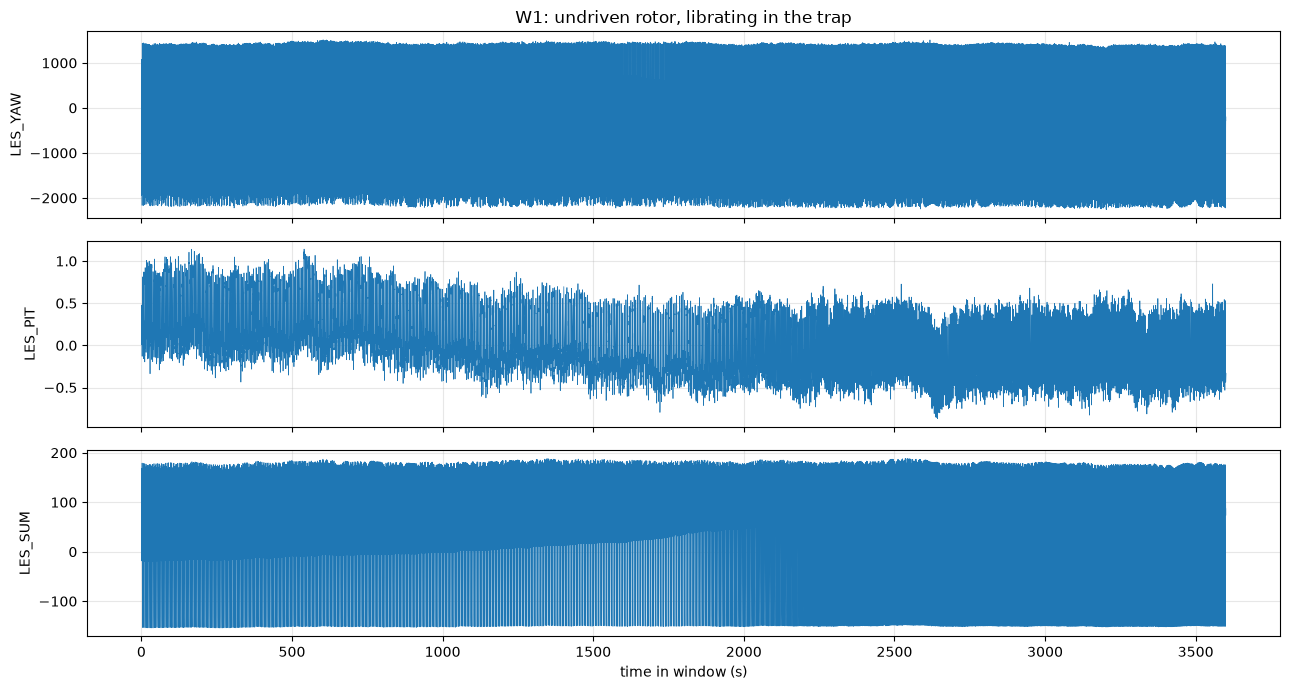

In [3]:
fig, ax = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
w = 'W1'; fs = D[w]['fs']
for i,k in enumerate(('YAW','PIT','SUM')):
    y = decimate(decimate(D[w][k]-D[w][k].mean(), 8, ftype='fir'), 8, ftype='fir')
    t = np.arange(len(y))/(fs/64)
    ax[i].plot(t, y, lw=.5)
    ax[i].set_ylabel(f'LES_{k}')
    ax[i].grid(alpha=.3)
ax[-1].set_xlabel('time in window (s)')
ax[0].set_title(f'{w}: undriven rotor, librating in the trap')
plt.tight_layout(); plt.show()

## 3. The survey — PSD 0–100 Hz

Log-log, all three channels, both windows overlaid. **A real mode sits at the same frequency in both traces.**

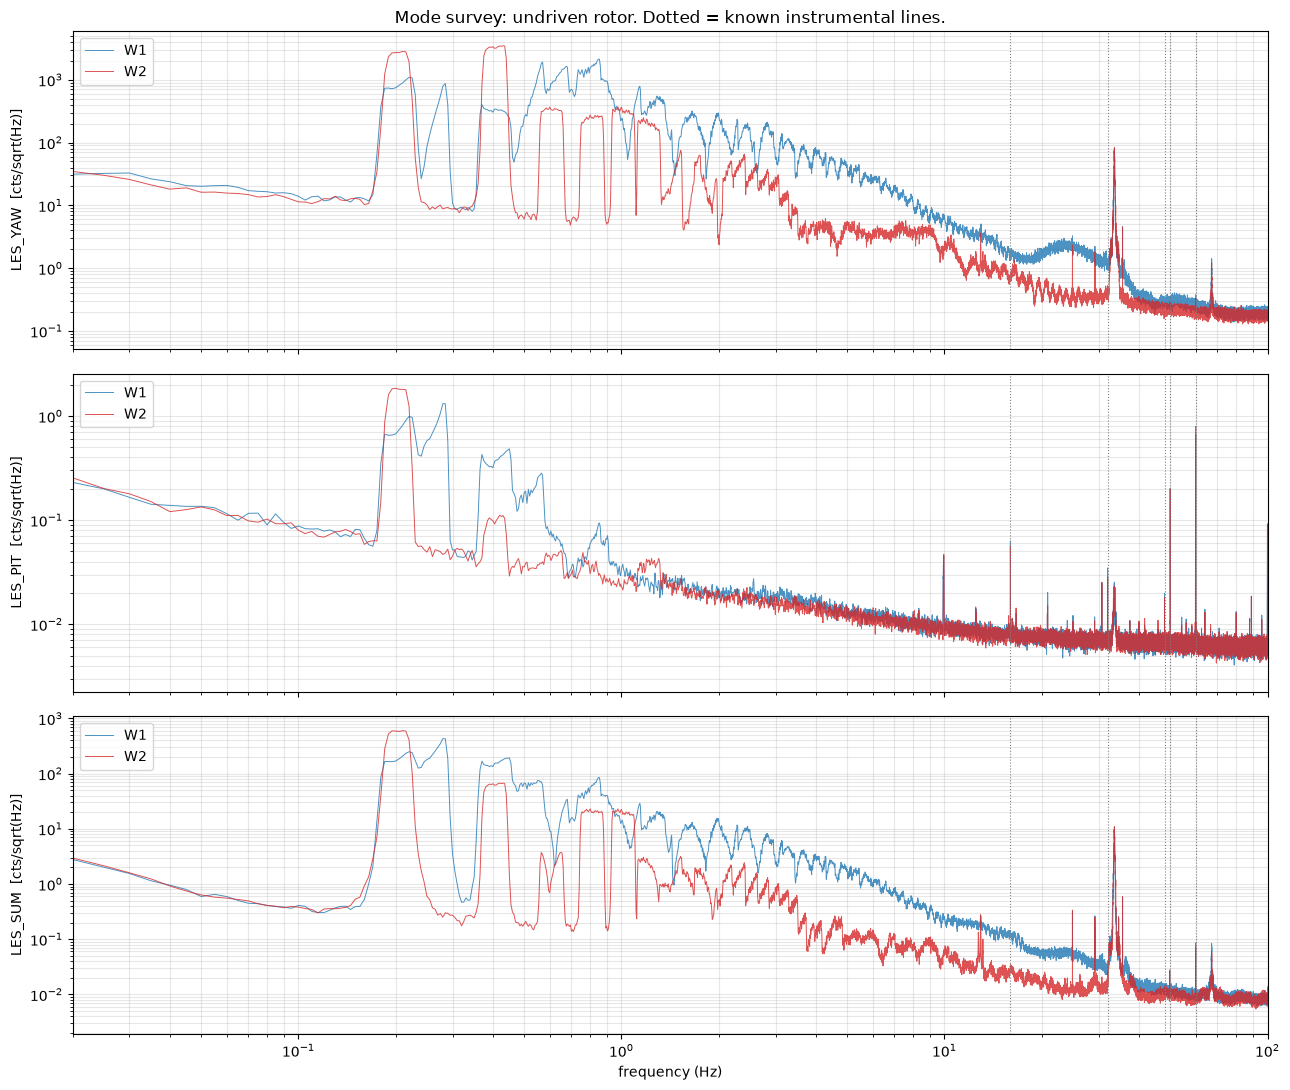

In [4]:
def psd(x, fs, seg=200.0, dec=4):
    y = decimate(x - x.mean(), dec, ftype='fir')
    fsd = fs/dec
    f, P = welch(y, fsd, nperseg=int(seg*fsd), noverlap=int(seg*fsd/2))
    return f, P

fig, ax = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
PS = {}
for i,k in enumerate(('YAW','PIT','SUM')):
    for w,c in zip(WINDOWS, ('tab:blue','tab:red')):
        f, P = psd(D[w][k], D[w]['fs'])
        PS[(w,k)] = (f,P)
        ax[i].loglog(f, np.sqrt(P), lw=.7, color=c, alpha=.8, label=w)
    ax[i].set_ylabel(f'LES_{k}  [cts/sqrt(Hz)]')
    ax[i].grid(alpha=.3, which='both'); ax[i].legend()
    for fr,lbl in [(60,'60 Hz'),(50,'50'),(16,'16'),(32,'32'),(48,'48')]:
        ax[i].axvline(fr, color='gray', ls=':', lw=.8)
ax[-1].set_xlabel('frequency (Hz)'); ax[0].set_xlim(0.02, 100)
ax[0].set_title('Mode survey: undriven rotor. Dotted = known instrumental lines.')
plt.tight_layout(); plt.show()

## 4. Zoom: the rigid-body band, 0.02–2 Hz

This is where a levitated rotor's translation, rocking and libration modes live.

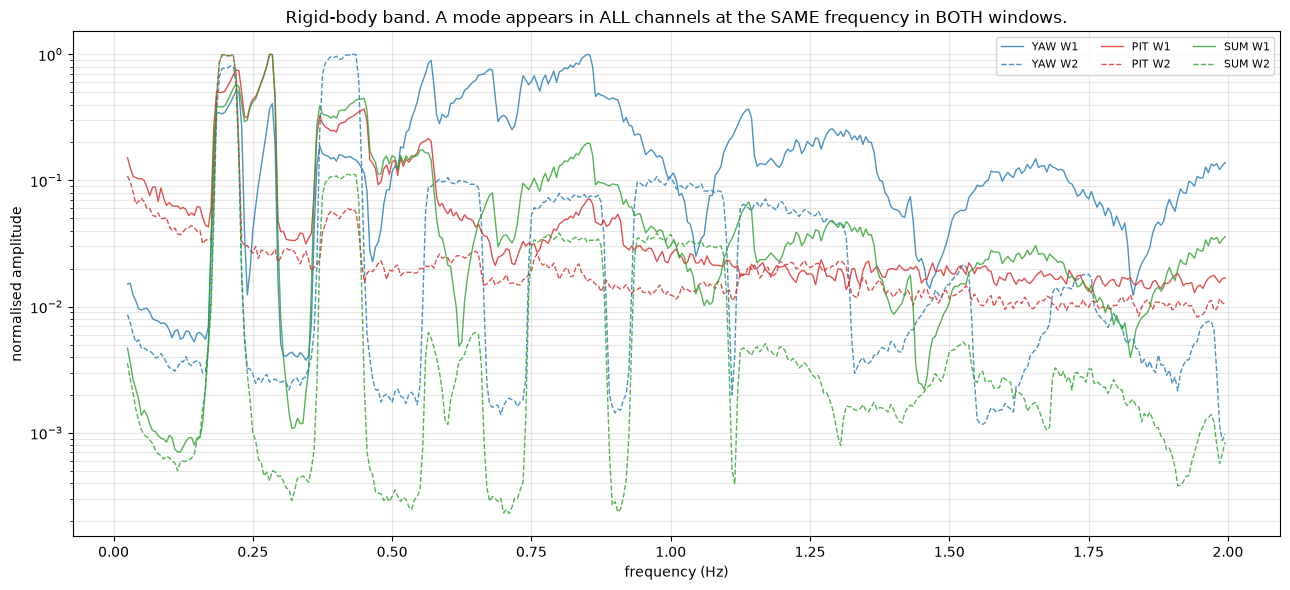

In [5]:
fig, ax = plt.subplots(figsize=(13, 6))
for k,c in zip(('YAW','PIT','SUM'), ('tab:blue','tab:red','tab:green')):
    for w,ls in zip(WINDOWS, ('-','--')):
        f,P = PS[(w,k)]
        m = (f>0.02)&(f<2.0)
        # normalise each channel so they can share an axis
        ax.semilogy(f[m], np.sqrt(P[m])/np.sqrt(P[m]).max(), ls, lw=1,
                    color=c, alpha=.8, label=f'{k} {w}')
ax.set_xlabel('frequency (Hz)'); ax.set_ylabel('normalised amplitude')
ax.grid(alpha=.3, which='both'); ax.legend(ncol=3, fontsize=8)
ax.set_title('Rigid-body band. A mode appears in ALL channels at the SAME frequency in BOTH windows.')
plt.tight_layout(); plt.show()

## 5. Automated peak list

Peaks are local maxima at least 8× above a running-median background. Reported per channel per window so persistence can be read off directly.

In [6]:
def peaks(f, P, fmin=0.02, fmax=100, thresh=8.0, nmax=20):
    df = f[1]-f[0]
    m = (f>fmin)&(f<fmax)
    fb, Pb = f[m], P[m]
    amp = np.sqrt(2*Pb*df)
    snr = Pb/np.maximum(median_filter(Pb, size=201), 1e-30)
    out=[]
    for i in range(2, len(fb)-2):
        if Pb[i]==max(Pb[i-2:i+3]) and snr[i]>thresh:
            out.append((fb[i], amp[i], snr[i]))
    out.sort(key=lambda r:-r[2]); keep=[]
    for fr,a,s in out:
        if all(abs(fr-k[0]) > max(0.02, 0.03*fr) for k in keep): keep.append((fr,a,s))
        if len(keep)>=nmax: break
    return sorted(keep)

PK={}
for k in ('YAW','PIT','SUM'):
    for w in WINDOWS:
        f,P = PS[(w,k)]
        PK[(w,k)] = peaks(f,P)
    print(f'=== LES_{k} ===')
    print(f'   {"W1 freq":>9} {"amp":>9} {"SNR":>8}    {"W2 freq":>9} {"amp":>9} {"SNR":>8}')
    a1, a2 = PK[('W1',k)], PK[('W2',k)]
    used=set()
    for fr,am,s in a1:
        match=[(j,q) for j,q in enumerate(a2)
               if j not in used and abs(q[0]-fr) < max(0.01, 0.02*fr)]
        if match:
            j,q = match[0]; used.add(j)
            print(f'   {fr:9.4f} {am:9.3f} {s:8.1f}    {q[0]:9.4f} {q[1]:9.3f} {q[2]:8.1f}')
        else:
            print(f'   {fr:9.4f} {am:9.3f} {s:8.1f}    {"--":>9} {"":>9} {"":>8}')
    for j,q in enumerate(a2):
        if j not in used:
            print(f'   {"--":>9} {"":>9} {"":>8}    {q[0]:9.4f} {q[1]:9.3f} {q[2]:8.1f}')
    print()

=== LES_YAW ===
     W1 freq       amp      SNR      W2 freq       amp      SNR
      0.2200   109.282     37.2           --                   
      0.2850    87.058     10.5           --                   
      0.5700   191.376     22.7           --                   
      0.6750   163.676      9.7           --                   
      0.7350   144.890     12.9           --                   
      0.7900   157.711     12.5           --                   
      0.8500   214.115     19.6           --                   
     33.5800     8.102    118.6      33.5850     8.387     66.8
     35.5850     0.457     25.3      35.5850     0.453    147.7
     67.1350     0.143     17.4      67.1550     0.122     14.2
          --                          0.2100   281.966  42977.7
          --                          0.4000   335.863  45843.2
          --                          0.4300   347.492  46089.4
          --                         12.9350     0.364     11.0
          --            

=== LES_SUM ===
     W1 freq       amp      SNR      W2 freq       amp      SNR
      0.1850    16.603    110.2           --                   
      0.2200    24.923    248.2           --                   
      0.2800    43.068    355.6           --                   
      0.3700    16.835     54.3           --                   
      0.4500    19.276     28.1           --                   
      0.8500     8.504     16.8           --                   
     24.9000     0.032     33.8      24.9000     0.034    737.0
     29.2250     0.026     54.9      29.2200     0.025    190.2
     33.5800     1.052    122.1      33.5850     1.102     77.1
     35.5850     0.057    404.0      35.5850     0.059    781.8
     59.9450     0.007     47.4      59.9400     0.009     92.9
     67.1350     0.008     14.0      67.1550     0.006     12.7
          --                          0.2100    59.985 1316830.9
          --                          0.4000     6.535  12742.1
          --           

## 6. Persistence: which lines are real modes?

A line present in **both** windows at the **same** frequency is a mode. A line that moves between windows is following the libration amplitude as it decays, so it is a harmonic of the libration, not an independent degree of freedom.

In [7]:
# Persistence alone is NOT enough: mains and digital lines are perfectly stable
# too. Exclude known instrumental frequencies before calling anything a mode.
INSTRUMENTAL = [(50.0,0.05),(60.0,0.10),(16.0,0.01),(32.0,0.01),(48.0,0.01),
                (64.0,0.01),(80.0,0.01),(96.0,0.01),(100.0,0.05)]
def is_instr(fr):
    return any(abs(fr-f0) <= tol for f0,tol in INSTRUMENTAL)

print('CANDIDATE MECHANICAL MODES -- same frequency in both windows,')
print('and not a known instrumental line:\n')
print(f'   {"chan":>5} {"W1 (Hz)":>9} {"W2 (Hz)":>9} {"shift":>9} {"amp":>9}')
seen=set()
for k in ('YAW','PIT','SUM'):
    for fr,am,s in PK[('W1',k)]:
        m=[q for q in PK[('W2',k)] if abs(q[0]-fr) < max(0.01, 0.02*fr)]
        if not m or is_instr(fr): continue
        if abs(m[0][0]-fr) > max(0.005, 0.005*fr): continue
        print(f'   {k:>5} {fr:9.4f} {m[0][0]:9.4f} {m[0][0]-fr:+9.4f} {am:9.3f}')
        seen.add(round(fr,2))

print('\nEXCLUDED as instrumental (stable, but not mechanical):')
for k in ('YAW','PIT','SUM'):
    for fr,am,s in PK[('W1',k)]:
        if is_instr(fr) and [q for q in PK[('W2',k)] if abs(q[0]-fr)<max(0.01,0.02*fr)]:
            print(f'   {k:>5} {fr:9.4f} Hz  amp {am:8.3f}')

print('\nDRIFTING between windows -> libration harmonics, NOT fixed modes:')
for k in ('YAW','PIT','SUM'):
    for w,other in (('W1','W2'),):
        for fr,am,s in PK[(w,k)]:
            if fr < 2.0 and not [q for q in PK[(other,k)]
                                 if abs(q[0]-fr) < max(0.01,0.02*fr)]:
                print(f'   {k:>5} {fr:9.4f} Hz  amp {am:8.3f}')
print('\nNOTE the entire 0.02-2 Hz band drifts. No FIXED rigid-body mode was')
print('found there -- every low-frequency line moves with the libration')
print('amplitude as it decays.')

CANDIDATE MECHANICAL MODES -- same frequency in both windows,
and not a known instrumental line:

    chan   W1 (Hz)   W2 (Hz)     shift       amp
     YAW   33.5800   33.5850   +0.0050     8.102
     YAW   35.5850   35.5850   +0.0000     0.457
     YAW   67.1350   67.1550   +0.0200     0.143
     PIT    9.9450    9.9500   +0.0050     0.005
     PIT   30.7150   30.7100   -0.0050     0.003
     PIT   89.1700   89.1350   -0.0350     0.002
     SUM   24.9000   24.9000   +0.0000     0.032
     SUM   29.2250   29.2200   -0.0050     0.026
     SUM   33.5800   33.5850   +0.0050     1.052
     SUM   35.5850   35.5850   +0.0000     0.057
     SUM   67.1350   67.1550   +0.0200     0.008

EXCLUDED as instrumental (stable, but not mechanical):
     PIT   16.0000 Hz  amp    0.006
     PIT   32.0000 Hz  amp    0.003
     PIT   49.9950 Hz  amp    0.020
     PIT   59.9450 Hz  amp    0.067
     SUM   59.9450 Hz  amp    0.007

DRIFTING between windows -> libration harmonics, NOT fixed modes:
     YAW   

## 7. The 33.6 Hz line

Well above the rigid-body band, not a round number, strong in YAW and SUM but absent from PIT — with a second harmonic near 67 Hz. Worth a closer look: coherence between channels says whether it is one physical motion or independent noise in each.

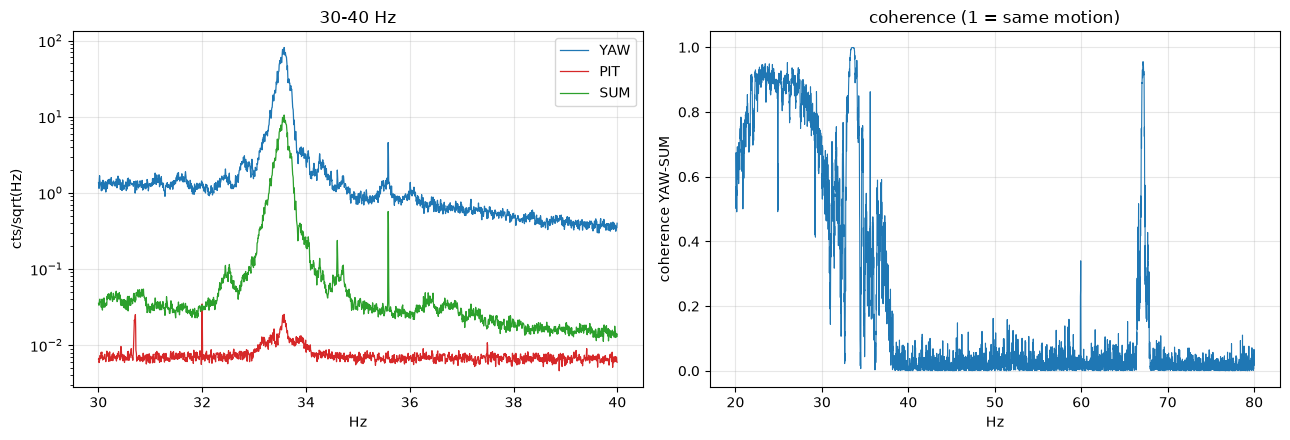

coherence at 33.58 Hz = 0.999
  high  -> one physical motion seen by both channels
  low   -> independent noise, likely electronic


In [8]:
w='W1'; fs=D[w]['fs']
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for k,c in zip(('YAW','PIT','SUM'), ('tab:blue','tab:red','tab:green')):
    f,P = PS[(w,k)]
    m=(f>30)&(f<40)
    ax[0].semilogy(f[m], np.sqrt(P[m]), lw=.9, color=c, label=k)
ax[0].set_xlabel('Hz'); ax[0].set_ylabel('cts/sqrt(Hz)'); ax[0].legend()
ax[0].grid(alpha=.3); ax[0].set_title('30-40 Hz')

# coherence: is it the same physical motion in YAW and SUM?
dec=4
ya=decimate(D[w]['YAW']-D[w]['YAW'].mean(), dec, ftype='fir')
su=decimate(D[w]['SUM']-D[w]['SUM'].mean(), dec, ftype='fir')
fc,Cxy = coherence(ya, su, fs/dec, nperseg=int(100*fs/dec))
m=(fc>20)&(fc<80)
ax[1].plot(fc[m], Cxy[m], lw=.8)
ax[1].set_xlabel('Hz'); ax[1].set_ylabel('coherence YAW-SUM')
ax[1].grid(alpha=.3); ax[1].set_title('coherence (1 = same motion)')
plt.tight_layout(); plt.show()
i=np.argmin(np.abs(fc-33.58))
print(f'coherence at 33.58 Hz = {Cxy[i]:.3f}')
print('  high  -> one physical motion seen by both channels')
print('  low   -> independent noise, likely electronic')

## Conclusions

*(fill in after running)*

**What to take away:**
1. Which low-frequency lines persist across both windows — those are the rigid-body modes, and they are what the drive could resonantly excite.
2. Whether 33.6 Hz is mechanical (coherent across channels) or electronic.
3. Whether any mode sits near a drive frequency or its harmonics. The drive has reached `f_elec` 4 Hz, so its fundamental spans 0.3–4 Hz — any mode in that band is directly drivable.

**Open:** none of this is yet connected to the wobble seen under drive. That needs a driven dataset with the drive frequency stepped across a candidate mode, watching for the response to grow. This notebook only establishes where the modes are.